# Real fusion task: respiratory rate from ECG + PPG (the intuition)

We test whether multimodal fusion (esp. neural fields) helps when the useful signal is a
**buried, low-energy factor shared across modalities**. The real instantiation:

- **Inputs:** two waveforms from BIDMC (PhysioNet) — **ECG** (lead II) and **PPG** (PLETH).
- **What we predict:** the **respiratory rate (RR, breaths/min)**.
- **Why it's the right task:** *respiration* modulates BOTH ECG (respiratory sinus
  arrhythmia) and PPG (baseline/amplitude), but it is **faint** next to the dominant
  cardiac signal — exactly the "buried shared factor" our hypothesis is about. Ground
  truth RR comes from BIDMC's dedicated `RESP` channel.
- **Metric:** mean absolute error (MAE, bpm), bracketed by a no-skill floor and a
  classical DSP ceiling.

In [1]:
import sys, os, glob
sys.path.insert(0, os.path.abspath('..'))
%matplotlib inline
import numpy as np, matplotlib.pyplot as plt
from scipy.signal import find_peaks, resample
from src.real.bidmc_rr import (_load, _bandpass, rr_from_resp, rr_from_ecg, rr_from_ppg,
                               RRConfig, octave_background, _apply_snr)
FS = 125.0; cfg = RRConfig()
path = sorted(glob.glob('../data/bidmc/*_Signals.csv'))[0]
ecg, ppg, resp = _load(path)
print('record:', os.path.basename(path), '| duration:', round(len(ecg)/FS), 's | 125 Hz')

record: bidmc_01_Signals.csv | duration: 480 s | 125 Hz


## 1. The inputs: two fast cardiac signals + a slow respiration signal
ECG and PPG oscillate at the **heart rate** (~1 Hz, the dominant/easy feature). RESP
oscillates at the **respiratory rate** (~0.2–0.4 Hz) — that's what we want, and it is
*not* the dominant rhythm in ECG/PPG.

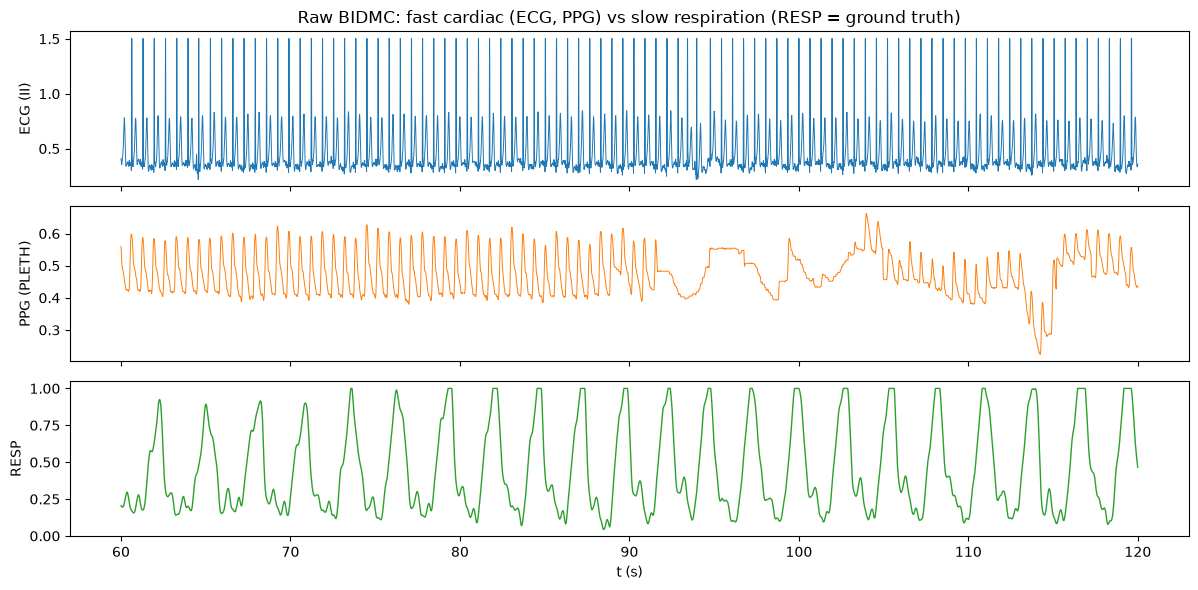

In [2]:
t = np.arange(len(ecg))/FS
sl = (t >= 60) & (t < 120)                      # a 60-second view
fig, ax = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
ax[0].plot(t[sl], ecg[sl], lw=.7); ax[0].set_ylabel('ECG (II)')
ax[1].plot(t[sl], ppg[sl], lw=.7, color='C1'); ax[1].set_ylabel('PPG (PLETH)')
ax[2].plot(t[sl], resp[sl], lw=1.0, color='C2'); ax[2].set_ylabel('RESP'); ax[2].set_xlabel('t (s)')
ax[0].set_title('Raw BIDMC: fast cardiac (ECG, PPG) vs slow respiration (RESP = ground truth)')
plt.tight_layout(); plt.show()

## 2. The buried shared factor: respiration hides inside ECG and PPG
- **ECG** carries respiration in **respiratory sinus arrhythmia** — breathing subtly
  speeds/slows the heart, modulating R-peak *timing/amplitude*. It is **deeply buried**.
- **PPG** carries respiration in its **baseline/amplitude** (band 0.1–0.6 Hz) — more
  **accessible**. Green = the true RESP trace, scaled, overlaid for comparison.

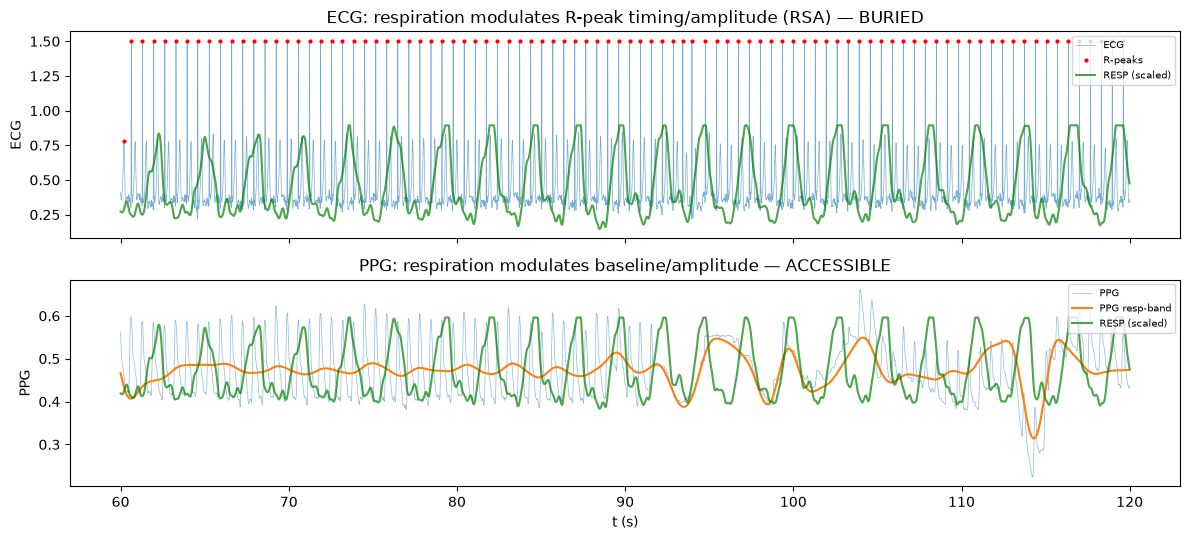

In [3]:
chunk = slice(int(60*FS), int(120*FS))
e, p, r = ecg[chunk], ppg[chunk], resp[chunk]; tc = np.arange(len(e))/FS + 60
rs = (r - r.mean())/(r.std()+1e-8)              # scaled resp for overlay
fig, ax = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True)
x = (e - np.median(e))/(e.std()+1e-8); pk,_ = find_peaks(x, distance=int(0.4*FS), prominence=1.0)
ax[0].plot(tc, e, lw=.5, alpha=.6, label='ECG'); ax[0].plot(tc[pk], e[pk], 'r.', ms=4, label='R-peaks')
ax[0].plot(tc, rs*e.std()+e.mean(), 'g', alpha=.7, label='RESP (scaled)')
ax[0].legend(fontsize=7, loc='upper right'); ax[0].set_ylabel('ECG')
ax[0].set_title('ECG: respiration modulates R-peak timing/amplitude (RSA) — BURIED')
env = _bandpass(p, FS, 0.1, 0.6)               # PPG respiratory band
ax[1].plot(tc, p, lw=.5, alpha=.5, label='PPG'); ax[1].plot(tc, env + p.mean(), 'C1', lw=1.5, label='PPG resp-band')
ax[1].plot(tc, rs*p.std()+p.mean(), 'g', alpha=.7, label='RESP (scaled)')
ax[1].legend(fontsize=7, loc='upper right'); ax[1].set_ylabel('PPG'); ax[1].set_xlabel('t (s)')
ax[1].set_title('PPG: respiration modulates baseline/amplitude — ACCESSIBLE')
plt.tight_layout(); plt.show()

## 3. What we predict: respiratory rate, and how classical DSP reads it
Target RR = breaths/min from the RESP channel. A classical estimate takes the dominant
frequency in the respiratory band (0.1–0.6 Hz). PPG's resp-band peak matches RESP well;
ECG's (via R-R intervals) is much noisier — quantifying "accessible vs buried".

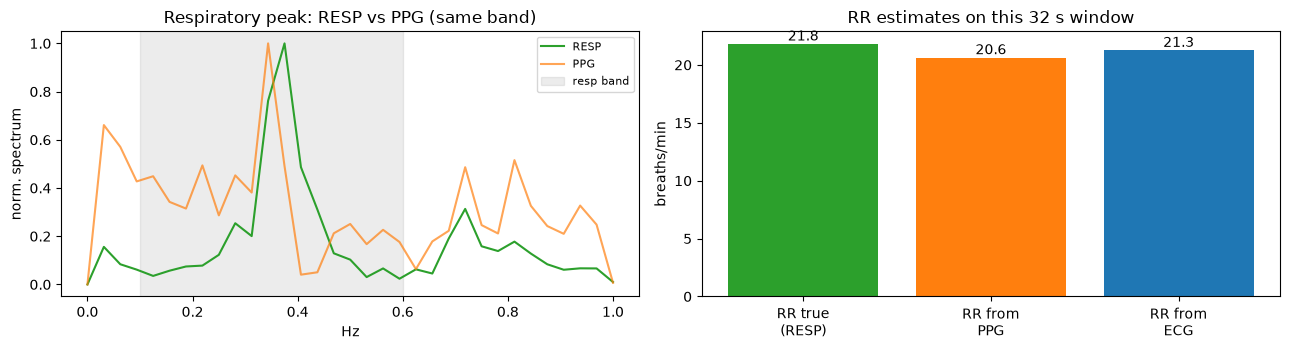

target RR=21.8 | classical PPG=20.6 | classical ECG=21.3 bpm


In [4]:
w = int(32*FS); s = int(60*FS)
rw, pw, ew = resp[s:s+w], ppg[s:s+w], ecg[s:s+w]
rr_true = rr_from_resp(rw, cfg)
rr_ppg  = rr_from_ppg(pw, FS, cfg)
rr_ecg  = rr_from_ecg(ew, FS, cfg)
def spec(x):
    X = np.abs(np.fft.rfft(x - x.mean())); f = np.fft.rfftfreq(len(x), 1/FS); return f, X
fr, Xr = spec(rw); fp, Xp = spec(pw)
m = fr <= 1.0
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
ax[0].plot(fr[m], Xr[m]/Xr[m].max(), 'C2', label='RESP'); ax[0].plot(fp[m], Xp[m]/Xp[m].max(), 'C1', alpha=.7, label='PPG')
ax[0].axvspan(cfg.resp_lo, cfg.resp_hi, color='grey', alpha=.15, label='resp band')
ax[0].set_xlabel('Hz'); ax[0].set_ylabel('norm. spectrum'); ax[0].legend(fontsize=8)
ax[0].set_title('Respiratory peak: RESP vs PPG (same band)')
ax[1].bar(['RR true\n(RESP)','RR from\nPPG','RR from\nECG'], [rr_true, rr_ppg, rr_ecg],
          color=['C2','C1','C0'])
ax[1].set_ylabel('breaths/min'); ax[1].set_title('RR estimates on this 32 s window')
for i,v in enumerate([rr_true,rr_ppg,rr_ecg]): ax[1].text(i, v+0.3, f'{v:.1f}', ha='center')
plt.tight_layout(); plt.show()
print(f'target RR={rr_true:.1f} | classical PPG={rr_ppg:.1f} | classical ECG={rr_ecg:.1f} bpm')

## 4. What the model sees: a window pair → one number (RR)
Each training example is an **(ECG window, PPG window)** pair (downsampled: ECG@64 Hz,
PPG@32 Hz, different grids) and the model outputs a **single scalar = predicted RR**.
We compare **unimodal** (ECG-only, PPG-only) vs **fusion** (late / early / neural-field).

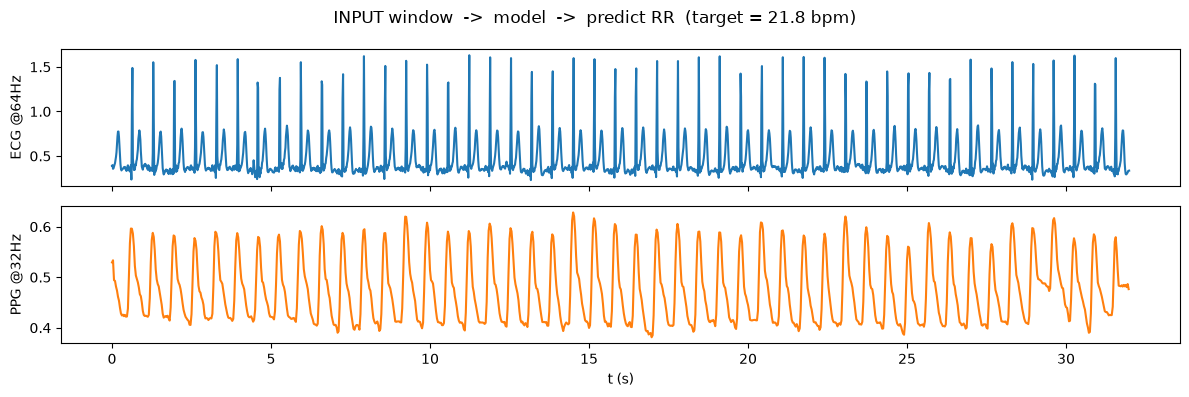

In [5]:
ecg_in = resample(ew, int(32*cfg.ecg_rate)); ppg_in = resample(pw, int(32*cfg.ppg_rate))
fig, ax = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
ax[0].plot(np.arange(len(ecg_in))/cfg.ecg_rate, ecg_in); ax[0].set_ylabel('ECG @64Hz')
ax[1].plot(np.arange(len(ppg_in))/cfg.ppg_rate, ppg_in, color='C1'); ax[1].set_ylabel('PPG @32Hz'); ax[1].set_xlabel('t (s)')
fig.suptitle(f'INPUT window  ->  model  ->  predict RR  (target = {rr_true:.1f} bpm)')
plt.tight_layout(); plt.show()

## 5. The metric and the brackets (what "good" means)
**MAE (bpm)**, lower is better, between two reference lines:
- **Floor** = predicting the mean RR (no skill).
- **Ceiling/bracket** = a trivial classical DSP estimator (FFT peak of PPG).

Bars are results from the GPU run (BIDMC, 53 records, 3 seeds, with band-pass preprocessing).
The honest current finding: **the neural models barely beat the floor and are ~2× worse
than classical PPG** — they aren't learning the periodicity a DSP gets for free; and the
neural-field arms here *underperform* a plain CNN (`late`).

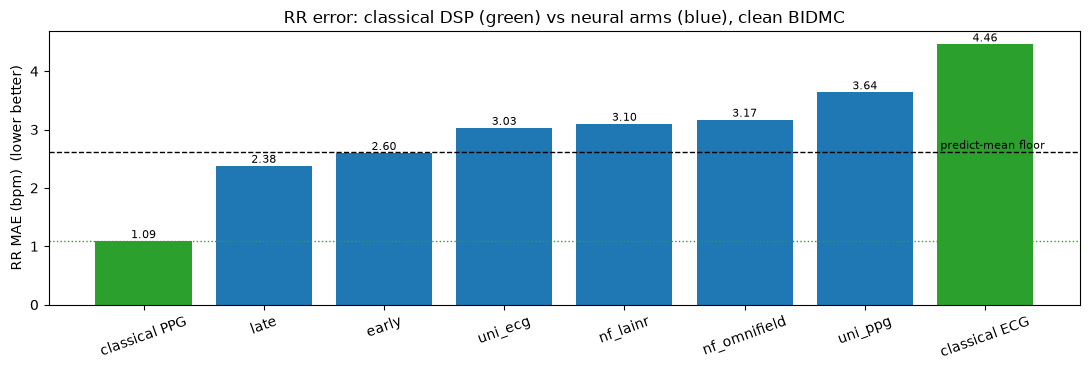

In [6]:
floor = 2.62                                   # predict-mean MAE (no skill)
res = {'classical PPG':1.09,'late':2.38,'early':2.60,'uni_ecg':3.03,
       'nf_lainr':3.10,'nf_omnifield':3.17,'uni_ppg':3.64,'classical ECG':4.46}
names=list(res); vals=[res[k] for k in names]
colors=['#2ca02c' if 'classical' in k else '#1f77b4' for k in names]
fig, ax = plt.subplots(figsize=(11,3.8))
ax.bar(names, vals, color=colors)
ax.axhline(floor, color='k', ls='--', lw=1); ax.text(len(names)-0.5, floor+0.05, 'predict-mean floor', ha='right', fontsize=8)
ax.axhline(res['classical PPG'], color='#2ca02c', ls=':', lw=1)
ax.set_ylabel('RR MAE (bpm)  (lower better)')
ax.set_title('RR error: classical DSP (green) vs neural arms (blue), clean BIDMC')
for i,v in enumerate(vals): ax.text(i, v+0.05, f'{v:.2f}', ha='center', fontsize=8)
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

## 6. Why we then *degrade* PPG (the actual fusion test)
On clean data PPG alone nearly solves RR, so fusion has nothing to add. The hypothesis can
only be tested when the *easy* modality is broken: inject motion noise into PPG so its
respiratory signal is buried, and ask whether fusion holds RR by leaning on the **buried
ECG** respiration. Below: clean vs noisy PPG, and how the classical PPG estimate collapses.

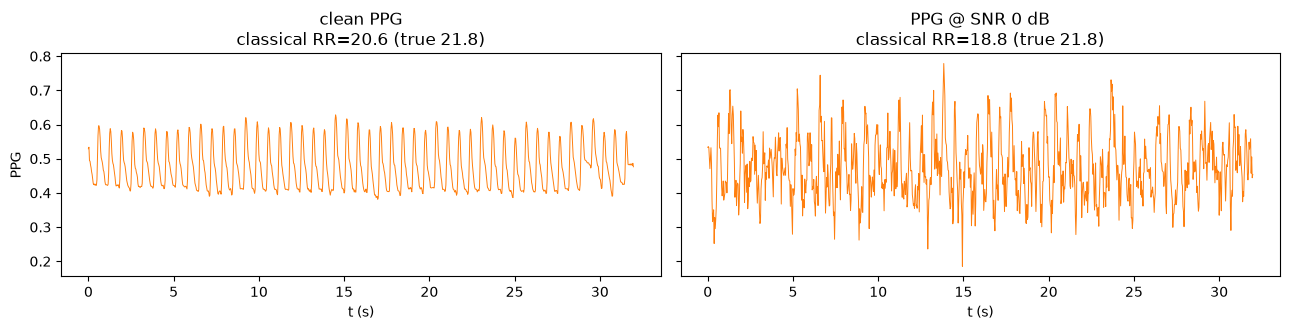

In [7]:
rng = np.random.default_rng(0)
fig, ax = plt.subplots(1, 2, figsize=(13, 3.4), sharey=True)
for j, snr in enumerate([None, 0.0]):
    pp = ppg_in.copy()
    if snr is not None:
        nb = octave_background(rng, len(pp), cfg.ppg_rate, 6, 1.0)
        noisy, _ = _apply_snr(pp - pp.mean(), nb, snr); pp = (noisy + pp.mean())
    rr_p = rr_from_ppg(pp, cfg.ppg_rate, cfg)
    ax[j].plot(np.arange(len(pp))/cfg.ppg_rate, pp, color='C1', lw=.7)
    ax[j].set_title(('clean PPG' if snr is None else f'PPG @ SNR {snr:g} dB') +
                    f'\nclassical RR={rr_p:.1f} (true {rr_true:.1f})'); ax[j].set_xlabel('t (s)')
ax[0].set_ylabel('PPG')
plt.tight_layout(); plt.show()

## Summary — the intuition in one paragraph
We predict **respiratory rate** from **ECG + PPG**. Respiration is a **faint factor shared
across both** (RSA in ECG, baseline in PPG) — the real version of a "buried signal".
Metric is **MAE (bpm)**, read against a **predict-mean floor** and a **classical-DSP
bracket**. The fusion hypothesis: when one modality (PPG) is degraded, a model that
*preserves the buried factor* should hold RR by using the other (ECG). So far on real
data the neural models sit near the floor and below the classical bracket — an *extraction*
gap, not a fusion success — which is why the next step is giving the encoders a
periodicity-aware front-end before re-running the PPG-degradation sweep.